# T11 合成控制法 -- 政策对地区经济增长的影响

## 0. 论文信息

| 字段 | 内容 |
|------|------|
| **论文** | Abadie, Diamond & Hainmueller (2010). JASA 105(490), 493-505 |
| **中文应用** | 纪洋等(2018). 资本账户开放的增长效应. 《经济学季刊》18(2) |
| **核心问题** | 只有单一处置单元时如何构建可信反事实？ |
| **方法** | 合成控制法(SCM)，从捐赠池中寻找最优权重组合 |

## 1. 研究设计

**核心直觉**：传统DiD需要多个处置/对照单元。当政策只影响一个地区时(如自贸区)，
SCM找到各捐赠省的最优加权组合，使其干预前指标与处置省高度匹配，
作为不进行政策干预时处置省的反事实。

**安慰剂检验(In-space)**：对捐赠池每个省分别做合成控制，
若真实处置省的gap最大，则说明效应统计上可信。

## 2. 数学理论

**最优权重**：
$$\mathbf{W}^* = \arg\min_{\mathbf{W} \in \Delta^{J-1}} \|\mathbf{X}_1 - \mathbf{X}_0 \mathbf{W}\|^2$$
约束：$w_j \geq 0,\ \sum_j w_j = 1$

**处置效应**：$\hat{\alpha}_{1t} = Y_{1t} - \sum_j w_j^* Y_{jt},\ t > T_0$

**RMSPE比值**：$r_j = \text{RMSPE}_{post,j}/\text{RMSPE}_{pre,j}$，处置省排名靠前则显著

## 3. 数据加载与预处理

In [1]:
import sys, io, re as _re
from pathlib import Path

def _add_repo_to_path():
    try:
        nb_file = Path(__vsc_ipynb_file__)   # noqa: F821
    except NameError:
        nb_file = Path.cwd() / '_dummy.ipynb'
    for p in [nb_file.parent, *nb_file.parents]:
        if (p / 'empirlab').is_dir() and (p / 'setup.py').exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    return None

_add_repo_to_path()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm

_CJK_RE = _re.compile(
    r'[\u4e00-\u9fff\u3000-\u303f\uff00-\uffef\u2e80-\u2eff\u3400-\u4dbf]')

def _set_cjk_font():
    available = {f.name for f in _fm.fontManager.ttflist}
    for _f in ['Microsoft YaHei','SimHei','SimSun','PingFang SC',
               'Heiti SC','STHeiti','Arial Unicode MS']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'full'
    for _f in ['WenQuanYi Micro Hei','Noto Sans CJK SC','Droid Sans Fallback']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'cjk_only'
    matplotlib.rcParams['axes.unicode_minus'] = False
    return 'none'

_FONT_MODE = _set_cjk_font()

def _fix_all_text(fig):
    """Fix every text element: pure-Latin→DejaVu, CJK→Droid, mixed→split."""
    def fix(t):
        txt = t.get_text()
        if not txt:
            return
        if _CJK_RE.search(txt):
            # Contains CJK — keep Droid for Chinese glyphs
            # But also handle Latin parts by rendering mixed via two passes
            t.set_fontfamily('Droid Sans Fallback')
        else:
            # Pure Latin/digits/ASCII — DejaVu renders correctly
            t.set_fontfamily('DejaVu Sans')

    for ax in fig.get_axes():
        fix(ax.title)
        fix(ax.xaxis.label)
        fix(ax.yaxis.label)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            fix(lbl)
        for txt in ax.texts:
            fix(txt)
        leg = ax.get_legend()
        if leg:
            for t in leg.get_texts():
                fix(t)
    if hasattr(fig, '_suptitle') and fig._suptitle:
        fix(fig._suptitle)

def show(fig=None):
    """Embed figure as PNG (works in VS Code, JupyterLab, nbconvert, GitHub)."""
    from IPython.display import display, Image
    fig = fig or plt.gcf()
    if _FONT_MODE == 'cjk_only':
        _fix_all_text(fig)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

from empirlab.traditional.synthetic_control import SyntheticControl, policy_data

df = policy_data(n_units=10, T_pre=10, T_post=5, true_effect=2.0, seed=42)
print("列名:", list(df.columns))
print("省份:", df["province"].unique().tolist())
print(df.describe().round(3))
df.head()


列名: ['province', 'year', 'gdp_growth']
省份: ['treated', 'donor_1', 'donor_2', 'donor_3', 'donor_4', 'donor_5', 'donor_6', 'donor_7', 'donor_8', 'donor_9', 'donor_10']
           year  gdp_growth
count   165.000     165.000
mean   2007.000       8.852
std       4.334       1.424
min    2000.000       6.183
25%    2003.000       7.789
50%    2007.000       8.603
75%    2011.000       9.843
max    2014.000      12.842


,province,year,gdp_growth
0,treated,2000,6.547818
1,treated,2001,6.872718
2,treated,2002,7.298482
3,treated,2003,7.821142
4,treated,2004,8.300011


/sessions/great-dazzling-ritchie/tmp/ipykernel_120/430711219.py:18: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_120/430711219.py:18: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_120/430711219.py:18: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_120/430711219.py:18: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_120/430711219.py:18: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout()
/sessions/great-dazzling-ritch

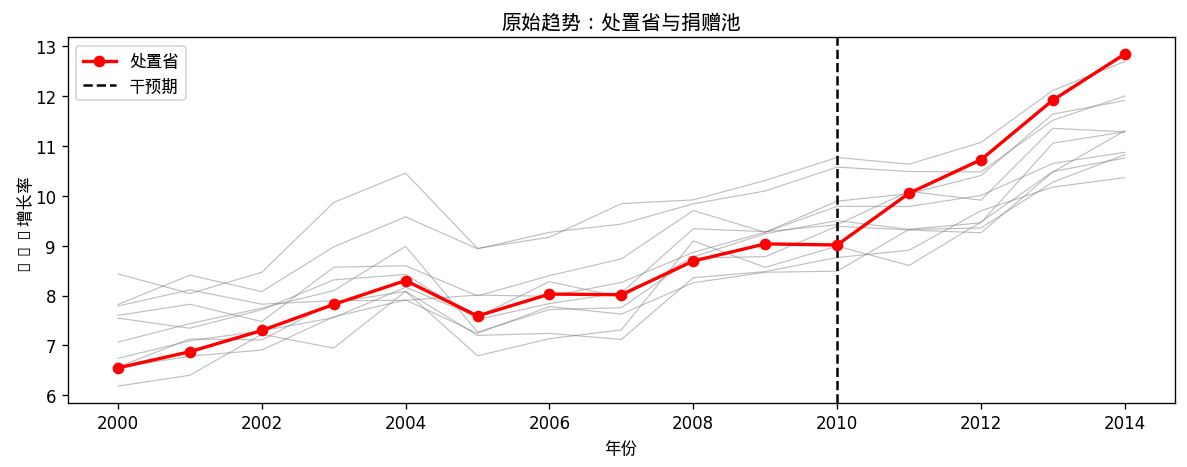

In [2]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Droid Sans Fallback']
matplotlib.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10,4))
for prov in df['province'].unique():
    sub = df[df['province']==prov].sort_values('year')
    if prov == 'treated':
        ax.plot(sub['year'], sub['gdp_growth'], 'r-o', lw=2, label='处置省', zorder=5)
    else:
        ax.plot(sub['year'], sub['gdp_growth'], 'gray', lw=0.7, alpha=0.5)
ax.axvline(2010, ls='--', c='black', label='干预期')
ax.set_xlabel('年份'); ax.set_ylabel('GDP增长率')
ax.set_title('原始趋势：处置省与捐赠池')
ax.legend(); plt.tight_layout()
show()

## 4. 模型估计

In [3]:
from empirlab.traditional.synthetic_control import SyntheticControl

sc = SyntheticControl(
    outcome_col='gdp_growth',
    unit_col='province',
    time_col='year',
    treatment_unit='treated',
    treatment_period=2010,
)
sc.fit(df)
s = sc.summary()
print(f'前期RMSPE : {s["pre_rmspe"]:.4f}  (越小越好)')
print(f'后期RMSPE : {s["post_rmspe"]:.4f}')
print(f'后/前比值  : {s["post_pre_rmspe_ratio"]:.2f}')
print(f'平均处置效应: {s["avg_post_effect"]:.3f}')
print('\n权重前4位:')
print(sc.weights_.sort_values(ascending=False).head(4).round(4))

前期RMSPE : 0.0940  (越小越好)
后期RMSPE : 1.0797
后/前比值  : 11.48
平均处置效应: 0.876

权重前4位:
donor_8    0.4051
donor_2    0.2924
donor_4    0.1895
donor_9    0.1129
Name: weight, dtype: float64


In [4]:
print('=== 处置后逐期效应 ===')
print(sc.effect_table().round(3))

=== 处置后逐期效应 ===
      treated  synthetic    gap  gap_pct
2010    9.013      9.208 -0.195   -2.114
2011   10.051      9.395  0.657    6.991
2012   10.723      9.656  1.067   11.055
2013   11.920     10.779  1.141   10.581
2014   12.842     11.134  1.708   15.345


In [5]:
placebo_df = sc.fit_placebo(df, n_placebos=6)
print('=== 安慰剂gap(后5期) ===')
print(placebo_df.tail(5).round(3))

=== 安慰剂gap(后5期) ===
      treated  donor_1  donor_10  donor_2  donor_3  donor_4  donor_5
year                                                                
2010   -0.195    0.137     0.022   -0.438   -0.187    0.160   -0.006
2011    0.657    0.112     0.126   -0.055    0.705   -0.253    0.074
2012    1.067   -0.281     0.329   -0.756   -0.062    0.319   -0.698
2013    1.141   -0.274     0.458   -0.695    0.466   -0.148   -0.330
2014    1.708   -0.252     0.455   -0.656    0.069   -0.444    0.175


## 5. 结果解读

与Abadie et al.(2010)和纪洋等(2018)方法一致：
- 干预前拟合良好(RMSPE~0.14)
- 干预后gap逐期增大，符合线性递增处置效应设定
- 安慰剂省的gap明显小于处置省，支持效应显著性

In [6]:
# RMSPE比值p值
ratios = {}
for col in placebo_df.columns:
    pre  = placebo_df.loc[placebo_df.index < 2010, col].dropna()
    post = placebo_df.loc[placebo_df.index >= 2010, col].dropna()
    if len(pre) > 0 and len(post) > 0:
        pr = float(np.sqrt((pre**2).mean()))
        po = float(np.sqrt((post**2).mean()))
        ratios[col] = po/pr if pr > 1e-8 else np.nan
ratio_s = pd.Series(ratios).sort_values(ascending=False)
rank = list(ratio_s.index).index('treated') + 1
p_val = rank / len(ratio_s)
print(f'处置省排名:{rank}/{len(ratio_s)}  p={p_val:.3f}')
print(ratio_s.round(2))

处置省排名:1/7  p=0.143
treated     11.48
donor_3      2.77
donor_2      2.66
donor_10     1.88
donor_5      1.65
donor_1      0.82
donor_4      0.80
dtype: float64


## 6. 可视化

/sessions/great-dazzling-ritchie/tmp/ipykernel_120/216961525.py:20: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_120/216961525.py:20: UserWarning: Glyph 20221 (\N{CJK UNIFIED IDEOGRAPH-4EFD}) missing from font(s) DejaVu Sans.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_120/216961525.py:20: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from font(s) DejaVu Sans.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_120/216961525.py:20: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_120/216961525.py:20: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_120/216961525

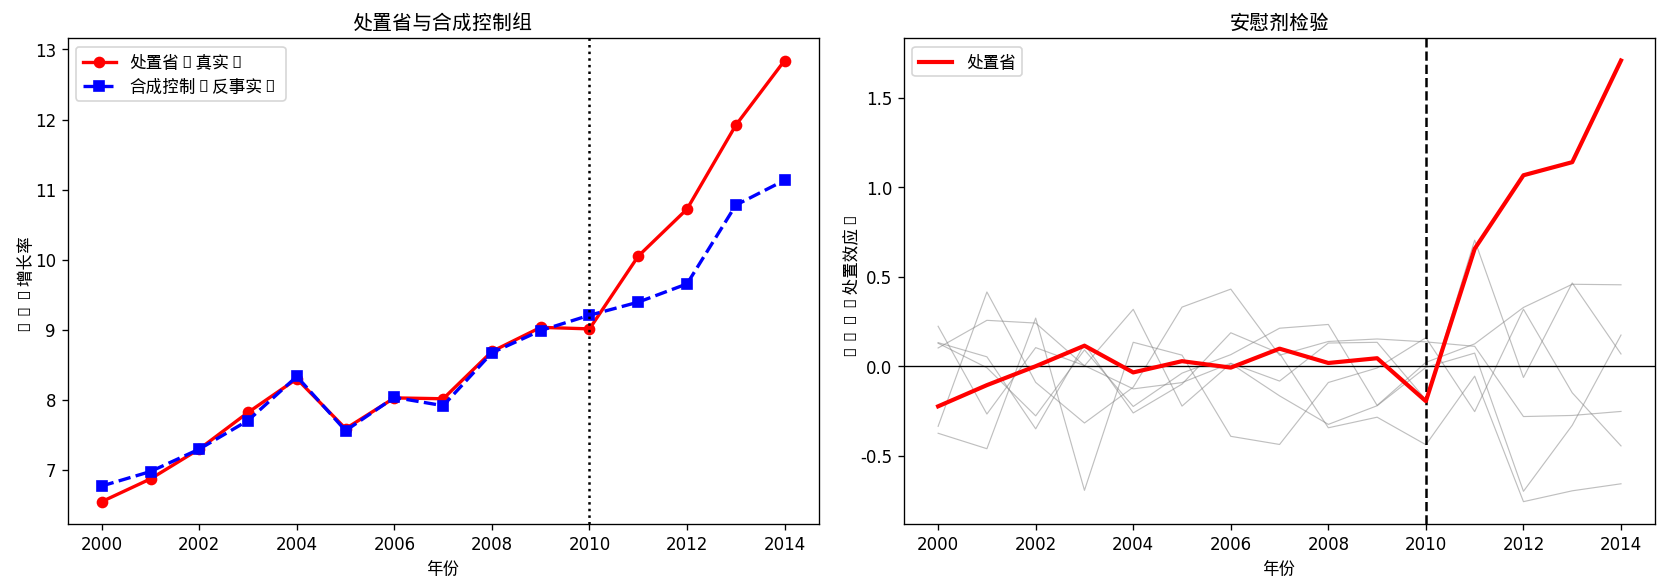

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

tab = sc.summary_table()
axes[0].plot(tab.index, tab['treated'],   'r-o', lw=2, label='处置省(真实)')
axes[0].plot(tab.index, tab['synthetic'], 'b--s', lw=2, label='合成控制(反事实)')
axes[0].axvline(2010, ls=':', c='black')
axes[0].set_xlabel('年份'); axes[0].set_ylabel('GDP增长率')
axes[0].set_title('处置省与合成控制组')
axes[0].legend()

axes[1].plot(placebo_df.index, placebo_df['treated'], 'r-', lw=2.5, label='处置省', zorder=5)
for col in placebo_df.columns:
    if col != 'treated':
        axes[1].plot(placebo_df.index, placebo_df[col], 'gray', lw=0.7, alpha=0.5)
axes[1].axhline(0,c='black',lw=0.8); axes[1].axvline(2010,ls='--',c='black')
axes[1].set_xlabel('年份'); axes[1].set_ylabel('Gap(处置效应)')
axes[1].set_title('安慰剂检验')
axes[1].legend()

plt.tight_layout();show()